In [2]:
import pandas as pd 
import matplotlib.pyplot as plt 
import re 

In [3]:
#loading the dataset
df = pd.read_csv(fr"D:\major project\Video_captioning_code\captions\msvd_captions.csv")


In [5]:
# 1. Checking missing captions

print("Missing English captions:", df['english_captions'].isnull().sum())
print("Missing Nepali captions:", df['nepali_captions'].isnull().sum())

Missing English captions: 0
Missing Nepali captions: 0


In [11]:
# Show all rows where either caption has only 1 word
rows_with_one_word = df[(df['eng_len'] == 1) | (df['nep_len'] == 1)]
print(rows_with_one_word[['english_captions', 'nepali_captions', 'eng_len', 'nep_len']])


      english_captions nepali_captions  eng_len  nep_len
207           the stem           स्टेम        2        1
1871                oh              ओह        1        1
5997             vijay            विजय        1        1
6143            a bear            भालु        2        1
6658             clara          क्लारा        1        1
...                ...             ...      ...      ...
72880              wow             वाह        1        1
74020            bears            भालु        1        1
76379             nane            nane        1        1
76474           enough        पर्याप्त        1        1
79282          on sale        बिक्रीमा        2        1

[72 rows x 4 columns]


In [13]:
print(df.iloc[0])


video_id                    -4wsuPCjDBc_5_15 
nepali_captions     एउटा चिपमङ्कले खाइरहेको छ
english_captions         a chipmunk is eating
eng_len                                     4
nep_len                                     4
Name: 0, dtype: object


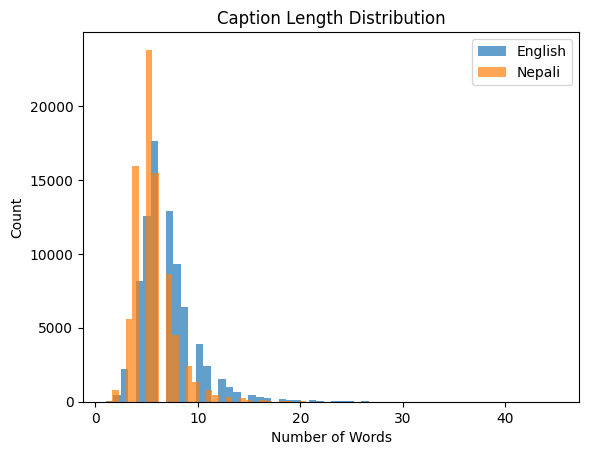

In [18]:
# 3. Histogram of caption lengths
plt.hist(df['eng_len'], bins=60, alpha=0.7, label='English')
plt.hist(df['nep_len'], bins=60, alpha=0.7, label='Nepali')
plt.xlabel("Number of Words")
plt.ylabel("Count")
plt.title("Caption Length Distribution")
plt.legend()
plt.show()

In [19]:
# English caption length percentiles
print("English Caption Length Percentiles:")
print(df['eng_len'].quantile([0.0, 0.25, 0.5, 0.75, 0.9, 0.95, 1.0]))

# Nepali caption length percentiles
print("\nNepali Caption Length Percentiles:")
print(df['nep_len'].quantile([0.0, 0.25, 0.5, 0.75, 0.9, 0.95, 1.0]))


English Caption Length Percentiles:
0.00     1.0
0.25     5.0
0.50     6.0
0.75     8.0
0.90    10.0
0.95    12.0
1.00    45.0
Name: eng_len, dtype: float64

Nepali Caption Length Percentiles:
0.00     1.0
0.25     4.0
0.50     5.0
0.75     6.0
0.90     8.0
0.95     9.0
1.00    40.0
Name: nep_len, dtype: float64


In [15]:
# 4. Duplicate captions
print("Duplicate English captions:", df['english_captions'].duplicated().sum())
print("Duplicate Nepali captions:", df['nepali_captions'].duplicated().sum())

Duplicate English captions: 18981
Duplicate Nepali captions: 24227
